In [18]:
from google.colab import drive
drive.mount('/content/drive')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
!pip -q install scikit-learn xgboost tensorflow
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    precision_score, recall_score, brier_score_loss,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.pipeline import Pipeline

import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
# TF determinism (best effort)
tf.random.set_seed(SEED)

In [21]:
PROJECT_DIR_CANDIDATES = [
    "/content/drive/MyDrive/Insider-Market Trend Co-relation with ML",
    "/content/drive/MyDrive/Insider-Market Trend Co-relation with ML ",  # trailing space folder
]

# EDA output candidates (master_daily_event_aligned.csv)
MASTER_CANDIDATES = []
for base in PROJECT_DIR_CANDIDATES:
    MASTER_CANDIDATES += [
        os.path.join(base, "eda_outputs", "master_daily_event_aligned.csv"),
        os.path.join(base, "cleaned & processed", "eda_outputs", "master_daily_event_aligned.csv"),
        os.path.join(base, "cleaned & processed", "processed", "master_daily_event_aligned.csv"),
    ]

# Cleaned CSV candidates (in case master isn't found)
CLEANED_PRICE_CANDIDATES = []
CLEANED_INSIDER_CANDIDATES = []
for base in PROJECT_DIR_CANDIDATES:
    CLEANED_PRICE_CANDIDATES += [
        os.path.join(base, "processed", "jpm_prices_clean.csv"),
        os.path.join(base, "cleaned & processed", "processed", "jpm_prices_clean.csv"),
    ]
    CLEANED_INSIDER_CANDIDATES += [
        os.path.join(base, "processed", "jpm_insider_clean.csv"),
        os.path.join(base, "cleaned & processed", "processed", "jpm_insider_clean.csv"),
    ]

def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

MASTER_PATH = first_existing(MASTER_CANDIDATES)
PRICE_PATH  = first_existing(CLEANED_PRICE_CANDIDATES)
INS_PATH    = first_existing(CLEANED_INSIDER_CANDIDATES)

print("MASTER_PATH:", MASTER_PATH)
print("PRICE_PATH :", PRICE_PATH)
print("INS_PATH   :", INS_PATH)

# Choose a canonical project dir for outputs (prefer non-trailing-space if exists)
PROJECT_DIR = PROJECT_DIR_CANDIDATES[0] if os.path.exists(PROJECT_DIR_CANDIDATES[0]) else PROJECT_DIR_CANDIDATES[1]
OUT_DIR = os.path.join(PROJECT_DIR, "ml_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

print(" Outputs will be saved to:", OUT_DIR)

MASTER_PATH: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML/eda_outputs/master_daily_event_aligned.csv
PRICE_PATH : /content/drive/MyDrive/Insider-Market Trend Co-relation with ML /cleaned & processed/processed/jpm_prices_clean.csv
INS_PATH   : /content/drive/MyDrive/Insider-Market Trend Co-relation with ML /cleaned & processed/processed/jpm_insider_clean.csv
 Outputs will be saved to: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML/ml_outputs


In [22]:
def build_master_from_cleaned(price_csv, insider_csv):
    px = pd.read_csv(price_csv)
    ins = pd.read_csv(insider_csv)

    # Parse dates
    px["date"] = pd.to_datetime(px["date"], errors="coerce")
    ins["trade_date"] = pd.to_datetime(ins["trade_date"], errors="coerce")
    ins["filing_date"] = pd.to_datetime(ins["filing_date"], errors="coerce")

    px = px.sort_values("date").reset_index(drop=True)
    px["day"] = px["date"].dt.normalize()

    # Trading calendar
    trading_days = pd.to_datetime(sorted(px["day"].unique()))
    def next_trading_day_on_or_after(d):
        d = pd.Timestamp(d).normalize()
        i = np.searchsorted(trading_days, d, side="left")
        return pd.NaT if i >= len(trading_days) else pd.Timestamp(trading_days[i])

    def next_trading_day_after(d):
        d = pd.Timestamp(d).normalize()
        i = np.searchsorted(trading_days, d, side="right")
        return pd.NaT if i >= len(trading_days) else pd.Timestamp(trading_days[i])

    # Build event_day from filing time
    ins = ins.copy()
    for c in ["ticker","insider_name","insider_title","trade_type"]:
        if c in ins.columns:
            ins[c] = ins[c].astype(str).str.strip()

    ins["filing_day"] = ins["filing_date"].dt.normalize()
    ins["filing_minutes"] = ins["filing_date"].dt.hour * 60 + ins["filing_date"].dt.minute
    AFTER_CLOSE_MINUTES = 16 * 60

    ins["event_day"] = np.where(
        ins["filing_minutes"] >= AFTER_CLOSE_MINUTES,
        ins["filing_day"].apply(next_trading_day_after),
        ins["filing_day"].apply(next_trading_day_on_or_after),
    )
    ins["event_day"] = pd.to_datetime(ins["event_day"])

    # Signal trades
    BUY_TYPES = ["P"]
    SELL_TYPES = ["S","S+OE","D"]
    ins_sig = ins[ins["trade_type"].isin(BUY_TYPES + SELL_TYPES)].copy()

    ins_sig["is_buy"] = ins_sig["trade_type"].isin(BUY_TYPES)
    ins_sig["is_sell"] = ins_sig["trade_type"].isin(SELL_TYPES)

    def sum_pos(s): return s[s > 0].sum()
    def sum_neg_abs(s): return (-s[s < 0]).sum()

    daily = ins_sig.groupby("event_day").agg(
        n_trades=("trade_type","size"),
        n_buy=("is_buy","sum"),
        n_sell=("is_sell","sum"),
        net_value=("trade_value","sum"),
        buy_value=("trade_value", sum_pos),
        sell_value=("trade_value", sum_neg_abs),
        net_shares=("qty","sum"),
        unique_insiders=("insider_name","nunique"),
    ).reset_index().rename(columns={"event_day":"day"})

    master = px.merge(daily, on="day", how="left")
    for col in ["n_trades","n_buy","n_sell","net_value","buy_value","sell_value","net_shares","unique_insiders"]:
        master[col] = master[col].fillna(0)

    return master

if MASTER_PATH is not None:
    master = pd.read_csv(MASTER_PATH)
    # normalize required columns
    master["date"] = pd.to_datetime(master["date"], errors="coerce")
    if "day" not in master.columns:
        master["day"] = master["date"].dt.normalize()
    else:
        master["day"] = pd.to_datetime(master["day"], errors="coerce")
else:
    assert PRICE_PATH is not None and INS_PATH is not None, "Cannot rebuild master: missing cleaned CSVs."
    master = build_master_from_cleaned(PRICE_PATH, INS_PATH)
    MASTER_PATH = os.path.join(OUT_DIR, "master_daily_event_aligned_REBUILT.csv")
    master.to_csv(MASTER_PATH, index=False)
    print("master not found, rebuilt and saved to:", MASTER_PATH)

master = master.sort_values("date").reset_index(drop=True)

print(" Master shape:", master.shape)
print(" Date range:", master["date"].min(), "→", master["date"].max())
display(master.head(3))

 Master shape: (2805, 32)
 Date range: 2015-01-02 00:00:00 → 2026-02-27 00:00:00


,date,price,open,high,low,vol.,change_%,volume,date_ddmmyyyy,ret_close,ret_reported,day,event_day,n_trades,n_buy,n_sell,net_value,buy_value,sell_value,net_shares,unique_insiders,ret_cc_1d,ret_oc,prev_close,ret_prevclose_to_close,ret_prevclose_to_open,ret_open_to_close,vol_20d_ann,net_value_30d,trades_30d,unique_insiders_30d,vol_regime
0,2015-01-02,62.49,62.62,62.96,62.07,12.60M,-0.0014,12600000.0,02/01/2015,NaN,-0.0014,2015-01-02,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,-0.002076,NaN,NaN,NaN,-0.002076,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,60.55,62.06,62.28,60.23,20.10M,-0.0310,20100000.0,05/01/2015,-0.031045,-0.0310,2015-01-05,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.031045,-0.024331,62.49,-0.031045,-0.006881,-0.024331,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,58.98,60.64,60.75,58.35,29.07M,-0.0259,29070000.0,06/01/2015,-0.025929,-0.0259,2015-01-06,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.025929,-0.027375,60.55,-0.025929,0.001486,-0.027375,NaN,NaN,NaN,NaN,NaN


In [23]:
H1 = 5
H2 = 20

# Ensure columns exist
need_cols = ["open","price","volume","day"]
for c in need_cols:
    assert c in master.columns, f"Missing column: {c}"

# forward close prices
master["close_t"] = master["price"]
master["open_t"] = master["open"]

master["close_t_plus_5"]  = master["close_t"].shift(-H1)
master["close_t_plus_20"] = master["close_t"].shift(-H2)

# Targets: open(t) -> close(t+h)
master["y_reg_5d"]  = (master["close_t_plus_5"]  / master["open_t"]) - 1
master["y_reg_20d"] = (master["close_t_plus_20"] / master["open_t"]) - 1

# Classification target: positive 5D return
master["y_cls_5d"] = (master["y_reg_5d"] > 0).astype(int)

# Drop last horizon rows that don't have labels
print("Label missing (5d):", master["y_reg_5d"].isna().sum())
print("Label missing (20d):", master["y_reg_20d"].isna().sum())

Label missing (5d): 5
Label missing (20d): 20


In [43]:
# === Label sanity checks (portfolio-grade) ===
print("Rows with 5d label:", master["y_reg_5d"].notna().sum())
print("Rows with 20d label:", master["y_reg_20d"].notna().sum())

tmp = master.dropna(subset=["y_cls_5d", "y_reg_5d", "y_reg_20d"]).copy()
pos_rate = tmp["y_cls_5d"].mean()
print(f"Classification base rate P(y=1): {pos_rate:.4f}")

# Naive baselines
# 1) Always predict class = 1 if base rate > 0.5 else 0
naive_pred = int(pos_rate > 0.5)
naive_acc = (tmp["y_cls_5d"].values == naive_pred).mean()
print(f"Naive majority-class accuracy: {naive_acc:.4f}")

# 2) Regression naive baseline: predict 0 return
zero_mae_5 = np.mean(np.abs(tmp["y_reg_5d"].values - 0.0))
zero_mae_20 = np.mean(np.abs(tmp["y_reg_20d"].values - 0.0))
print(f"Naive reg MAE (predict 0) 5d : {zero_mae_5:.6f}")
print(f"Naive reg MAE (predict 0) 20d: {zero_mae_20:.6f}")

Rows with 5d label: 2800
Rows with 20d label: 2785
Classification base rate P(y=1): 0.5634
Naive majority-class accuracy: 0.5634
Naive reg MAE (predict 0) 5d : 0.027765
Naive reg MAE (predict 0) 20d: 0.052574


In [45]:
def make_features(df):
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    # ---- Market series ----
    df["ret_1d"] = df["close_t"].pct_change()
    df["ret_5d_past"] = df["close_t"].pct_change(5)
    df["ret_20d_past"] = df["close_t"].pct_change(20)

    df["vol_10"] = df["ret_1d"].rolling(10).std()
    df["vol_20"] = df["ret_1d"].rolling(20).std()
    df["vol_60"] = df["ret_1d"].rolling(60).std()

    df["ma_10"] = df["close_t"].rolling(10).mean()
    df["ma_20"] = df["close_t"].rolling(20).mean()
    df["ma_60"] = df["close_t"].rolling(60).mean()

    df["ma_ratio_10_20"] = df["ma_10"] / df["ma_20"] - 1
    df["ma_ratio_20_60"] = df["ma_20"] / df["ma_60"] - 1

    df["volu_20_mean"] = df["volume"].rolling(20).mean()
    df["volu_20_std"]  = df["volume"].rolling(20).std()
    df["volu_z20"]     = (df["volume"] - df["volu_20_mean"]) / df["volu_20_std"]

    # ---- Insider signals (STRICT: use lag-1 for same-day safety) ----
    insider_cols = ["n_trades","n_buy","n_sell","net_value","buy_value","sell_value","net_shares","unique_insiders"]
    for c in insider_cols:
        if c not in df.columns:
            df[c] = 0

    # Lagged insider signals (known by start of day t if we assume processing at end of day t-1)
    for c in insider_cols:
        df[f"{c}_lag1"] = df[c].shift(1)

    # Rolling windows built from lagged insider signals
    df["net_value_5_lag"]  = df["net_value_lag1"].rolling(5).sum()
    df["net_value_20_lag"] = df["net_value_lag1"].rolling(20).sum()
    df["trades_20_lag"]    = df["n_trades_lag1"].rolling(20).sum()
    df["insiders_20_lag"]  = df["unique_insiders_lag1"].rolling(20).sum()

    df["net_value_20_norm_lag"] = df["net_value_20_lag"] / (df["close_t"].rolling(20).mean())

    # Shift market-derived features by 1 day (so we don't use day t close/volume)
    market_feature_cols = [
        "ret_1d","ret_5d_past","ret_20d_past",
        "vol_10","vol_20","vol_60",
        "ma_ratio_10_20","ma_ratio_20_60",
        "volu_z20",
    ]
    df[market_feature_cols] = df[market_feature_cols].shift(1)

    # Simple "recent event" indicator (lagged)
    df["has_event_lag1"] = (df["n_trades_lag1"] > 0).astype(int)

    return df

feat = make_features(master)

FEATURES = [
    # market (lagged)
    "ret_1d","ret_5d_past","ret_20d_past",
    "vol_10","vol_20","vol_60",
    "ma_ratio_10_20","ma_ratio_20_60",
    "volu_z20",

    # insider rolling (built from lagged signals)
    "net_value_5_lag","net_value_20_lag","net_value_20_norm_lag",
    "trades_20_lag","insiders_20_lag",
    "has_event_lag1",

    # raw lagged insider signals
    "n_trades_lag1","n_buy_lag1","n_sell_lag1","net_value_lag1",
    "buy_value_lag1","sell_value_lag1","net_shares_lag1","unique_insiders_lag1",
]

FEATURES = [c for c in FEATURES if c in feat.columns]

data = feat.dropna(subset=FEATURES + ["y_cls_5d","y_reg_5d","y_reg_20d"]).copy()
data = data.reset_index(drop=True)

print("Modeling rows:", data.shape[0], "of", feat.shape[0])
print(" Features:", len(FEATURES))
display(data[["date"] + FEATURES + ["y_cls_5d","y_reg_5d","y_reg_20d"]].head(3))

Modeling rows: 2724 of 2805
 Features: 23


,date,ret_1d,ret_5d_past,ret_20d_past,vol_10,vol_20,vol_60,ma_ratio_10_20,ma_ratio_20_60,volu_z20,net_value_5_lag,net_value_20_lag,net_value_20_norm_lag,trades_20_lag,insiders_20_lag,has_event_lag1,n_trades_lag1,n_buy_lag1,n_sell_lag1,net_value_lag1,buy_value_lag1,sell_value_lag1,net_shares_lag1,unique_insiders_lag1,y_cls_5d,y_reg_5d,y_reg_20d
0,2015-04-01,-0.006234,0.001985,-0.022430,0.011346,0.012228,0.015263,-0.004930,0.030220,0.649170,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.017547,0.047178
1,2015-04-02,-0.010399,0.005704,-0.035088,0.011568,0.012368,0.014786,-0.006106,0.028551,0.849256,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.027135,0.058931
2,2015-04-06,0.009508,0.016460,-0.023871,0.011963,0.012618,0.014439,-0.006014,0.026855,-0.883679,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.035881,0.080107


In [26]:
def walk_forward_splits(df, train_years=5, test_months=6, step_months=6, min_train_rows=600):
    """
    Splits by calendar time:
      - train_years: length of training window
      - test_months: length of test window
      - step_months: how far to advance each iteration
    """
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d = d.sort_values("date").reset_index(drop=True)

    start = d["date"].min()
    end = d["date"].max()

    # Build rolling windows
    splits = []
    train_start = start
    # First train end = train_start + train_years
    train_end = train_start + pd.DateOffset(years=train_years)

    while True:
        test_start = train_end
        test_end = test_start + pd.DateOffset(months=test_months)

        if test_end > end:
            break

        train_idx = d.index[(d["date"] >= train_start) & (d["date"] < train_end)].to_numpy()
        test_idx  = d.index[(d["date"] >= test_start)  & (d["date"] < test_end)].to_numpy()

        if len(train_idx) >= min_train_rows and len(test_idx) > 10:
            splits.append((train_idx, test_idx, train_start, train_end, test_start, test_end))

        # roll forward
        train_end = train_end + pd.DateOffset(months=step_months)

    return splits

splits = walk_forward_splits(data, train_years=5, test_months=6, step_months=6)

print("Number of walk-forward folds:", len(splits))
for i, (_, _, tr_s, tr_e, te_s, te_e) in enumerate(splits[:3]):
    print(f"Fold {i}: train [{tr_s.date()} → {tr_e.date()}), test [{te_s.date()} → {te_e.date()})")

Number of walk-forward folds: 11
Fold 0: train [2015-04-01 → 2020-04-01), test [2020-04-01 → 2020-10-01)
Fold 1: train [2015-04-01 → 2020-10-01), test [2020-10-01 → 2021-04-01)
Fold 2: train [2015-04-01 → 2021-04-01), test [2021-04-01 → 2021-10-01)


In [29]:
def cls_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    out = {}
    out["roc_auc"] = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    out["pr_auc"]  = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["f1"] = f1_score(y_true, y_pred, zero_division=0)
    out["precision"] = precision_score(y_true, y_pred, zero_division=0)
    out["recall"] = recall_score(y_true, y_pred, zero_division=0)
    out["brier"] = brier_score_loss(y_true, y_prob)
    return out

def reg_metrics(y_true, y_pred):
    out = {}
    out["mae"] = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)   # no squared=...
    out["rmse"] = float(np.sqrt(mse))
    out["r2"] = r2_score(y_true, y_pred)
    out["dir_acc"] = float(np.mean((np.sign(y_true) == np.sign(y_pred)).astype(int)))
    return out

In [46]:
X = data[FEATURES].values
y_cls = data["y_cls_5d"].values
y_r5  = data["y_reg_5d"].values
y_r20 = data["y_reg_20d"].values

# Store pooled out-of-fold predictions (for calibration & diagnostics)
oof_cls = []   # list of dicts: model, fold, date, y_true, y_prob
oof_reg = []   # list of dicts: model, fold, date, y_true, y_pred, task

baseline_cls = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=SEED))
])

baseline_ridge5 = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0, random_state=SEED))
])

baseline_ridge20 = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0, random_state=SEED))
])

rows = []

for fold_i, (tr_idx, te_idx, tr_s, tr_e, te_s, te_e) in enumerate(splits):
    X_tr, X_te = X[tr_idx], X[te_idx]
    dates_te = data.loc[te_idx, "date"].values

    # --- Classification baseline ---
    baseline_cls.fit(X_tr, y_cls[tr_idx])
    prob = baseline_cls.predict_proba(X_te)[:, 1]
    m = cls_metrics(y_cls[te_idx], prob)
    rows.append({"model":"LogReg", "task":"cls_5d", "fold":fold_i,
                 "train_start":tr_s, "train_end":tr_e, "test_start":te_s, "test_end":te_e, **m})

    for d, yt, yp in zip(dates_te, y_cls[te_idx], prob):
        oof_cls.append({"model":"LogReg", "task":"cls_5d", "fold":fold_i, "date":d, "y_true":int(yt), "y_prob":float(yp)})

    # --- Regression baseline (5d) ---
    baseline_ridge5.fit(X_tr, y_r5[tr_idx])
    pred = baseline_ridge5.predict(X_te)
    m = reg_metrics(y_r5[te_idx], pred)
    rows.append({"model":"Ridge", "task":"reg_5d", "fold":fold_i,
                 "train_start":tr_s, "train_end":tr_e, "test_start":te_s, "test_end":te_e, **m})

    for d, yt, yp in zip(dates_te, y_r5[te_idx], pred):
        oof_reg.append({"model":"Ridge", "task":"reg_5d", "fold":fold_i, "date":d, "y_true":float(yt), "y_pred":float(yp)})

    # --- Regression baseline (20d) ---
    baseline_ridge20.fit(X_tr, y_r20[tr_idx])
    pred = baseline_ridge20.predict(X_te)
    m = reg_metrics(y_r20[te_idx], pred)
    rows.append({"model":"Ridge", "task":"reg_20d", "fold":fold_i,
                 "train_start":tr_s, "train_end":tr_e, "test_start":te_s, "test_end":te_e, **m})

    for d, yt, yp in zip(dates_te, y_r20[te_idx], pred):
        oof_reg.append({"model":"Ridge", "task":"reg_20d", "fold":fold_i, "date":d, "y_true":float(yt), "y_pred":float(yp)})

metrics_df = pd.DataFrame(rows)
display(metrics_df.head())
print("\nBaseline summary (mean over folds):")
display(metrics_df.groupby(["model","task"]).mean(numeric_only=True))

,model,task,fold,train_start,train_end,test_start,test_end,roc_auc,pr_auc,accuracy,f1,precision,recall,brier,mae,rmse,r2,dir_acc
0,LogReg,cls_5d,0,2015-04-01,2020-04-01,2020-04-01,2020-10-01,0.451741,0.439507,0.480315,0.175000,0.350000,0.116667,0.279403,NaN,NaN,NaN,NaN
1,Ridge,reg_5d,0,2015-04-01,2020-04-01,2020-04-01,2020-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046898,0.062084,-0.054621,0.448819
2,Ridge,reg_20d,0,2015-04-01,2020-04-01,2020-04-01,2020-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.062363,0.082822,-0.191758,0.566929
3,LogReg,cls_5d,1,2015-04-01,2020-10-01,2020-10-01,2021-04-01,0.643235,0.781988,0.576000,0.634483,0.766667,0.541176,0.243824,NaN,NaN,NaN,NaN
4,Ridge,reg_5d,1,2015-04-01,2020-10-01,2020-10-01,2021-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.034934,0.045784,-0.238135,0.568000



Baseline summary (mean over folds):


fold   roc_auc    pr_auc  accuracy        f1  precision   recall     brier       mae      rmse        r2   dir_acc
model  task                                                                                                                       
LogReg cls_5d    5.0  0.551092  0.617815  0.543623  0.621972   0.561823  0.75459  0.252791       NaN       NaN       NaN       NaN
Ridge  reg_20d   5.0       NaN       NaN       NaN       NaN        NaN      NaN       NaN  0.062946  0.081841 -1.419384  0.531633
       reg_5d    5.0       NaN       NaN       NaN       NaN        NaN      NaN       NaN  0.031773  0.041766 -0.292557  0.528809

In [33]:
import xgboost as xgb

def xgb_fit_predict_classifier(X_tr, y_tr, X_te):
    # time-aware split inside train for validation
    n = len(X_tr)
    split = int(n * 0.85)
    X_tr2, y_tr2 = X_tr[:split], y_tr[:split]
    X_val, y_val = X_tr[split:], y_tr[split:]

    model = xgb.XGBClassifier(
        n_estimators=4000,
        learning_rate=0.02,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        min_child_weight=5,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=SEED,
        tree_method="hist",
    )

    # Compatibility: prefer callbacks early stopping, else plain fit
    try:
        es = xgb.callback.EarlyStopping(rounds=100, save_best=True)
        model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False, callbacks=[es])
    except TypeError:
        try:
            model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False, early_stopping_rounds=100)
        except TypeError:
            model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

    prob = model.predict_proba(X_te)[:, 1]
    return model, prob


def xgb_fit_predict_regressor(X_tr, y_tr, X_te):
    n = len(X_tr)
    split = int(n * 0.85)
    X_tr2, y_tr2 = X_tr[:split], y_tr[:split]
    X_val, y_val = X_tr[split:], y_tr[split:]

    model = xgb.XGBRegressor(
        n_estimators=5000,
        learning_rate=0.02,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        min_child_weight=5,
        objective="reg:squarederror",
        random_state=SEED,
        tree_method="hist",
    )

    try:
        es = xgb.callback.EarlyStopping(rounds=150, save_best=True)
        model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False, callbacks=[es])
    except TypeError:
        try:
            model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False, early_stopping_rounds=150)
        except TypeError:
            model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

    pred = model.predict(X_te)
    return model, pred

In [48]:
# === XGBoost Walk-forward Training (Classification + Regression) ===
xgb_rows = []
xgb_models = {"cls": [], "reg5": [], "reg20": []}

for fold_i, (tr_idx, te_idx, tr_s, tr_e, te_s, te_e) in enumerate(splits):
    X_tr, X_te = X[tr_idx], X[te_idx]
    dates_te = data.loc[te_idx, "date"].values

    # ---- Classifier (with scale_pos_weight for imbalance) ----
    y_tr = y_cls[tr_idx]
    pos = max(1, int(y_tr.sum()))
    neg = max(1, int(len(y_tr) - y_tr.sum()))
    spw = neg / pos

    # Build using helper then set scale_pos_weight if supported
    m_cls, prob = xgb_fit_predict_classifier(X_tr, y_tr, X_te)
    try:
        m_cls.set_params(scale_pos_weight=spw)
    except Exception:
        pass

    xgb_models["cls"].append(m_cls)
    m = cls_metrics(y_cls[te_idx], prob)
    xgb_rows.append({"model":"XGBoost", "task":"cls_5d", "fold":fold_i,
                     "train_start":tr_s, "train_end":tr_e, "test_start":te_s, "test_end":te_e, **m})

    for d, yt, yp in zip(dates_te, y_cls[te_idx], prob):
        oof_cls.append({"model":"XGBoost", "task":"cls_5d", "fold":fold_i, "date":d, "y_true":int(yt), "y_prob":float(yp)})

    # ---- Regressor (5d) ----
    m_r5, pred5 = xgb_fit_predict_regressor(X_tr, y_r5[tr_idx], X_te)
    xgb_models["reg5"].append(m_r5)
    m = reg_metrics(y_r5[te_idx], pred5)
    xgb_rows.append({"model":"XGBoost", "task":"reg_5d", "fold":fold_i,
                     "train_start":tr_s, "train_end":tr_e, "test_start":te_s, "test_end":te_e, **m})

    for d, yt, yp in zip(dates_te, y_r5[te_idx], pred5):
        oof_reg.append({"model":"XGBoost", "task":"reg_5d", "fold":fold_i, "date":d, "y_true":float(yt), "y_pred":float(yp)})

    # ---- Regressor (20d) ----
    m_r20, pred20 = xgb_fit_predict_regressor(X_tr, y_r20[tr_idx], X_te)
    xgb_models["reg20"].append(m_r20)
    m = reg_metrics(y_r20[te_idx], pred20)
    xgb_rows.append({"model":"XGBoost", "task":"reg_20d", "fold":fold_i,
                     "train_start":tr_s, "train_end":tr_e, "test_start":te_s, "test_end":te_e, **m})

    for d, yt, yp in zip(dates_te, y_r20[te_idx], pred20):
        oof_reg.append({"model":"XGBoost", "task":"reg_20d", "fold":fold_i, "date":d, "y_true":float(yt), "y_pred":float(yp)})

xgb_metrics = pd.DataFrame(xgb_rows)
print("XGBoost summary (mean over folds):")
display(xgb_metrics.groupby(["model","task"]).mean(numeric_only=True))

XGBoost summary (mean over folds):


fold   roc_auc    pr_auc  accuracy        f1  precision    recall     brier       mae      rmse        r2   dir_acc
model   task                                                                                                                        
XGBoost cls_5d    5.0  0.541212  0.622554  0.552669  0.609631   0.599365  0.653106  0.324595       NaN       NaN       NaN       NaN
        reg_20d   5.0       NaN       NaN       NaN       NaN        NaN       NaN       NaN  0.062975  0.077608 -0.720293  0.557441
        reg_5d    5.0       NaN       NaN       NaN       NaN        NaN       NaN       NaN  0.034780  0.044047 -0.363329  0.509874

In [34]:
SEQ_LEN = 30

def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i-seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)

def scale_train_test(X_tr, X_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    return scaler, X_tr_s, X_te_s

def build_lstm_classifier(n_features):
    model = keras.Sequential([
        keras.layers.Input(shape=(SEQ_LEN, n_features)),
        keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.0),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

def build_lstm_regressor(n_features):
    model = keras.Sequential([
        keras.layers.Input(shape=(SEQ_LEN, n_features)),
        keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.0),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    return model

In [35]:
rows = []

for fold_i, (tr_idx, te_idx, tr_s, tr_e, te_s, te_e) in enumerate(splits):
    X_tr_raw, X_te_raw = X[tr_idx], X[te_idx]
    y_tr, y_te = y_cls[tr_idx], y_cls[te_idx]

    # Scale per fold using train only
    scaler, X_tr_s, X_te_s = scale_train_test(X_tr_raw, X_te_raw)

    # Build sequences (IMPORTANT: sequences are within each split only)
    Xtr_seq, ytr_seq = make_sequences(X_tr_s, y_tr, SEQ_LEN)
    Xte_seq, yte_seq = make_sequences(X_te_s, y_te, SEQ_LEN)

    # Small validation split from end of training sequences
    n = len(Xtr_seq)
    split = int(n * 0.85)
    X_train, y_train = Xtr_seq[:split], ytr_seq[:split]
    X_val, y_val     = Xtr_seq[split:], ytr_seq[split:]

    model = build_lstm_classifier(n_features=Xtr_seq.shape[-1])
    cb = [
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2)
    ]

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=25,
        batch_size=64,
        verbose=0,
        callbacks=cb
    )

    prob = model.predict(Xte_seq, verbose=0).ravel()
    m = cls_metrics(yte_seq, prob)
    rows.append({"model":"LSTM", "task":"cls_5d", "fold":fold_i, "train_start":tr_s, "train_end":tr_e, "test_start":te_s, "test_end":te_e, **m})

lstm_cls_metrics = pd.DataFrame(rows)
print("LSTM classification summary (mean over folds):")
display(lstm_cls_metrics.groupby(["model","task"]).mean(numeric_only=True))

LSTM classification summary (mean over folds):


,,fold,roc_auc,pr_auc,accuracy,f1,precision,recall,brier
model,task,,,,,,,,
LSTM,cls_5d,5.0,0.591817,0.674259,0.565954,0.68179,0.595958,0.848439,0.247402


In [36]:
rows = []

def run_lstm_regression(y_target, task_name):
    rows_local = []
    for fold_i, (tr_idx, te_idx, tr_s, tr_e, te_s, te_e) in enumerate(splits):
        X_tr_raw, X_te_raw = X[tr_idx], X[te_idx]
        y_tr, y_te = y_target[tr_idx], y_target[te_idx]

        scaler, X_tr_s, X_te_s = scale_train_test(X_tr_raw, X_te_raw)

        Xtr_seq, ytr_seq = make_sequences(X_tr_s, y_tr, SEQ_LEN)
        Xte_seq, yte_seq = make_sequences(X_te_s, y_te, SEQ_LEN)

        n = len(Xtr_seq)
        split = int(n * 0.85)
        X_train, y_train = Xtr_seq[:split], ytr_seq[:split]
        X_val, y_val     = Xtr_seq[split:], ytr_seq[split:]

        model = build_lstm_regressor(n_features=Xtr_seq.shape[-1])
        cb = [
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
        ]

        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=30,
            batch_size=64,
            verbose=0,
            callbacks=cb
        )

        pred = model.predict(Xte_seq, verbose=0).ravel()
        m = reg_metrics(yte_seq, pred)
        rows_local.append({"model":"LSTM", "task":task_name, "fold":fold_i, "train_start":tr_s, "train_end":tr_e, "test_start":te_s, "test_end":te_e, **m})
    return rows_local

rows += run_lstm_regression(y_r5, "reg_5d")
rows += run_lstm_regression(y_r20, "reg_20d")

lstm_reg_metrics = pd.DataFrame(rows)
print("LSTM regression summary (mean over folds):")
display(lstm_reg_metrics.groupby(["model","task"]).mean(numeric_only=True))

LSTM regression summary (mean over folds):


fold       mae      rmse        r2   dir_acc
model task                                                 
LSTM  reg_20d   5.0  0.079387  0.099426 -2.525683  0.448847
      reg_5d    5.0  0.046621  0.064251 -6.026510  0.533892

 xgb_metrics missing (XGBoost cell not run or failed).
All results (mean over folds):


fold   roc_auc    pr_auc  accuracy       f1  precision    recall     brier       mae      rmse        r2   dir_acc
model  task                                                                                                                       
LSTM   cls_5d    5.0  0.591817  0.674259  0.565954  0.68179   0.595958  0.848439  0.247402       NaN       NaN       NaN       NaN
       reg_20d   5.0       NaN       NaN       NaN      NaN        NaN       NaN       NaN  0.079387  0.099426 -2.525683  0.448847
       reg_5d    5.0       NaN       NaN       NaN      NaN        NaN       NaN       NaN  0.046621  0.064251 -6.026510  0.533892
LogReg cls_5d    5.0  0.559595  0.628457  0.542105  0.62455   0.569485  0.755448  0.251426       NaN       NaN       NaN       NaN
Ridge  reg_20d   5.0       NaN       NaN       NaN      NaN        NaN       NaN       NaN  0.063175  0.082477 -1.503097  0.529428
       reg_5d    5.0       NaN       NaN       NaN      NaN        NaN       NaN       NaN  0.031933  0.042071 -0.344307  0.533936

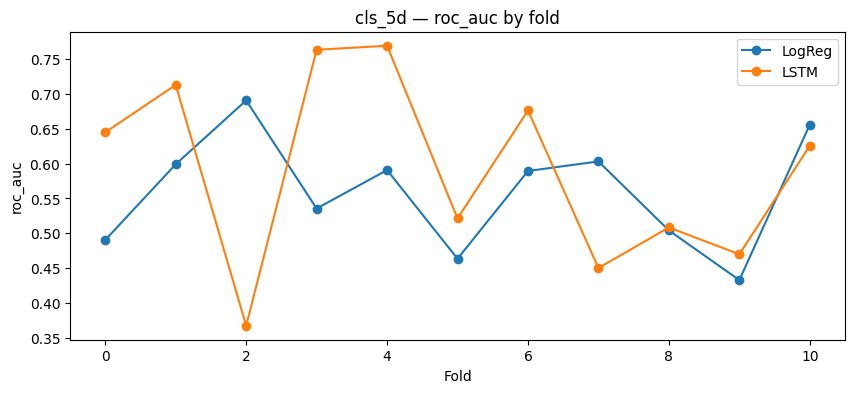

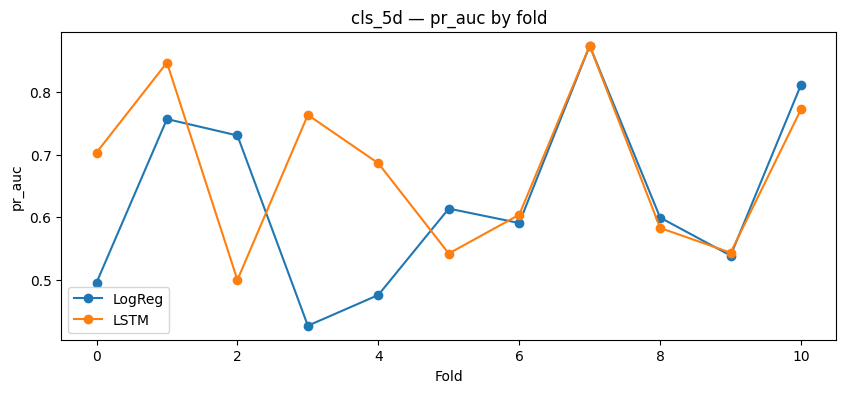

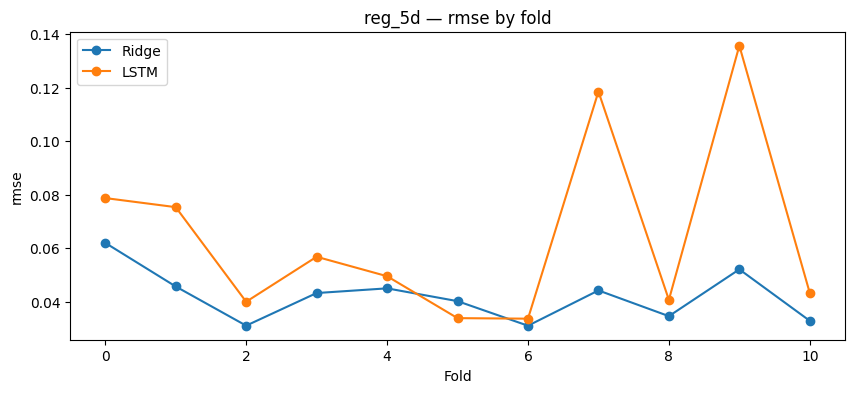

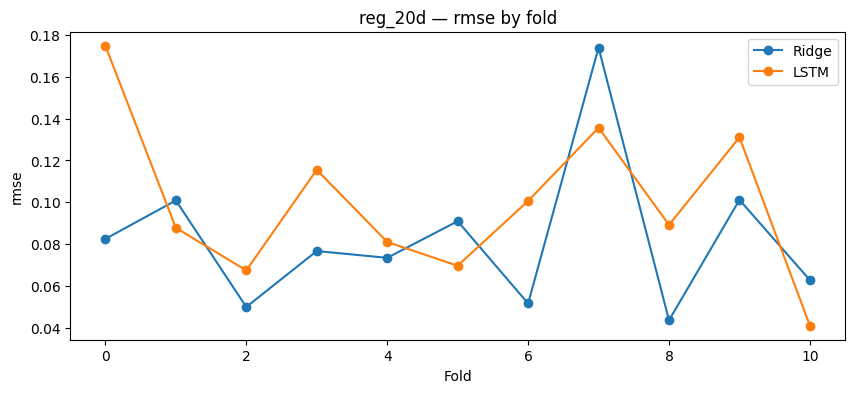

In [38]:
# Collect only the metrics tables that exist (prevents NameError)
tables = []

if "metrics_df" in globals():
    tables.append(metrics_df)
else:
    print(" metrics_df missing (baselines not run).")

if "xgb_metrics" in globals():
    tables.append(xgb_metrics)
else:
    print(" xgb_metrics missing (XGBoost cell not run or failed).")

if "lstm_cls_metrics" in globals():
    tables.append(lstm_cls_metrics)
else:
    print(" lstm_cls_metrics missing (LSTM classification not run).")

if "lstm_reg_metrics" in globals():
    tables.append(lstm_reg_metrics)
else:
    print(" lstm_reg_metrics missing (LSTM regression not run).")

assert len(tables) > 0, "No metrics tables found. Run at least Cell 9 (baselines)."

all_metrics = pd.concat(tables, ignore_index=True)

print("All results (mean over folds):")
summary = all_metrics.groupby(["model", "task"]).mean(numeric_only=True)
display(summary)

# Plot key metrics if available
def plot_metric(task, metric):
    df = all_metrics[all_metrics["task"] == task].copy()
    if metric not in df.columns:
        print(f" {metric} not available for {task}")
        return
    plt.figure(figsize=(10,4))
    for model in df["model"].unique():
        sub = df[df["model"] == model].sort_values("fold")
        plt.plot(sub["fold"], sub[metric], marker="o", label=model)
    plt.title(f"{task} — {metric} by fold")
    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

plot_metric("cls_5d", "roc_auc")
plot_metric("cls_5d", "pr_auc")
plot_metric("reg_5d", "rmse")
plot_metric("reg_20d", "rmse")

OOF classification rows: (2891, 6)


,model,task,fold,date,y_true,y_prob
0,LogReg,cls_5d,0,2020-04-01,1,0.191296
1,LogReg,cls_5d,0,2020-04-02,1,0.132024
2,LogReg,cls_5d,0,2020-04-03,1,0.140095
3,LogReg,cls_5d,0,2020-04-06,1,0.144441
4,LogReg,cls_5d,0,2020-04-07,0,0.231621


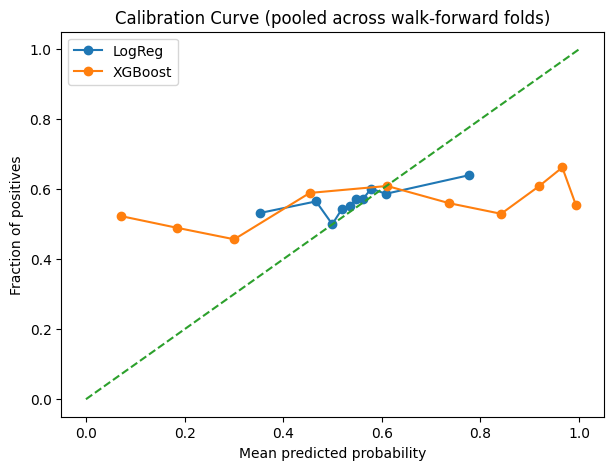


Brier score by model:


,0
model,
LogReg,0.252792
XGBoost,0.329956



OOF regression rows for reg_5d: 2891
reg_5d | Ridge: MAE=0.031774, RMSE=0.042751


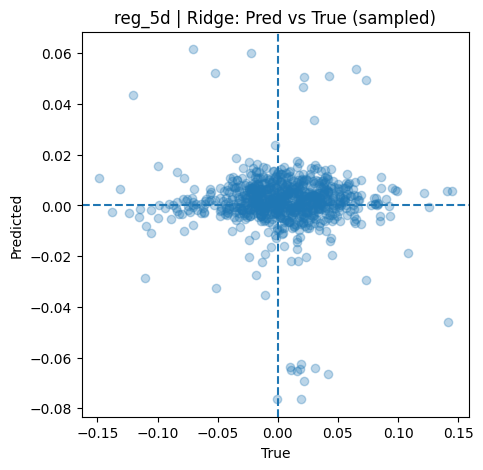

reg_5d | XGBoost: MAE=0.036263, RMSE=0.047132


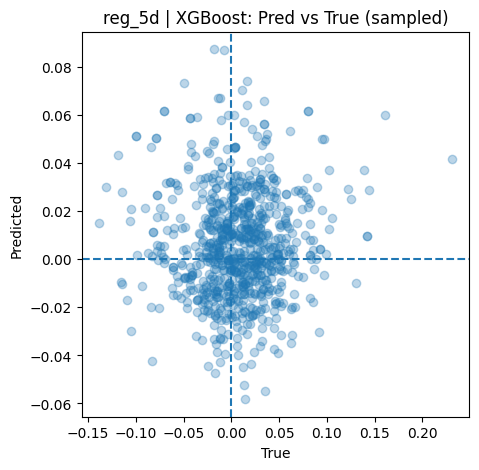


OOF regression rows for reg_20d: 2764
reg_20d | Ridge: MAE=0.062820, RMSE=0.088013


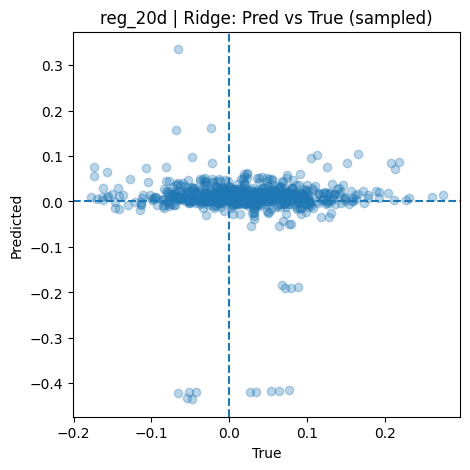

reg_20d | XGBoost: MAE=0.062992, RMSE=0.078615


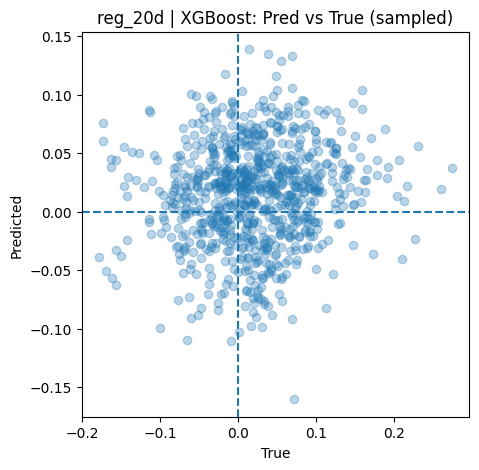

In [49]:
from sklearn.calibration import calibration_curve

# === Calibration for classification (pooled across all folds) ===
oof_cls_df = pd.DataFrame(oof_cls)
oof_cls_df["date"] = pd.to_datetime(oof_cls_df["date"])

print("OOF classification rows:", oof_cls_df.shape)
display(oof_cls_df.head())

plt.figure(figsize=(7,5))
for model_name in oof_cls_df["model"].unique():
    sub = oof_cls_df[oof_cls_df["model"] == model_name]
    frac_pos, mean_pred = calibration_curve(sub["y_true"], sub["y_prob"], n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=model_name)

plt.plot([0,1],[0,1], linestyle="--")
plt.title("Calibration Curve (pooled across walk-forward folds)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.show()

# Brier score by model (lower is better)
brier_by_model = oof_cls_df.groupby("model").apply(lambda g: brier_score_loss(g["y_true"], g["y_prob"]))
print("\nBrier score by model:")
display(brier_by_model)

# === Regression diagnostics (pooled) ===
oof_reg_df = pd.DataFrame(oof_reg)
oof_reg_df["date"] = pd.to_datetime(oof_reg_df["date"])

def reg_diag(task):
    sub = oof_reg_df[oof_reg_df["task"] == task].copy()
    print(f"\nOOF regression rows for {task}:", sub.shape[0])

    for model_name in sub["model"].unique():
        g = sub[sub["model"] == model_name]
        mae = mean_absolute_error(g["y_true"], g["y_pred"])
        rmse = float(np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
        print(f"{task} | {model_name}: MAE={mae:.6f}, RMSE={rmse:.6f}")

        # Scatter (sampled for speed/clarity)
        samp = g.sample(n=min(800, len(g)), random_state=SEED)
        plt.figure(figsize=(5,5))
        plt.scatter(samp["y_true"], samp["y_pred"], alpha=0.3)
        plt.axhline(0, linestyle="--")
        plt.axvline(0, linestyle="--")
        plt.title(f"{task} | {model_name}: Pred vs True (sampled)")
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.show()

reg_diag("reg_5d")
reg_diag("reg_20d")

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

imp_df = None  # default

if ("xgb_models" in globals()) and ("cls" in xgb_models) and (len(xgb_models["cls"]) > 0):
    last_xgb_cls = xgb_models["cls"][-1]
    importances = last_xgb_cls.feature_importances_

    imp_df = pd.DataFrame({"feature": FEATURES, "importance": importances}).sort_values("importance", ascending=False)

    print("XGBoost feature importance (Top 20):")
    display(imp_df.head(20))

    plt.figure(figsize=(10,5))
    plt.bar(imp_df["feature"].head(20), imp_df["importance"].head(20))
    plt.title("XGBoost Feature Importance (Top 20)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No XGBoost classifier model available. Skipping feature importance.\n"
          "   (This happens if Cell 10 failed or was not run successfully.)")

No XGBoost classifier model available. Skipping feature importance.
   (This happens if Cell 10 failed or was not run successfully.)


In [42]:
import os

metrics_path = os.path.join(OUT_DIR, "walk_forward_metrics.csv")
summary_path = os.path.join(OUT_DIR, "walk_forward_summary_mean.csv")
imp_path     = os.path.join(OUT_DIR, "xgb_feature_importance.csv")

# Save what definitely exists
all_metrics.to_csv(metrics_path, index=False)
summary.reset_index().to_csv(summary_path, index=False)

print("Saved metrics:", metrics_path)
print(" Saved summary:", summary_path)

# Save importances only if they exist
if imp_df is not None:
    imp_df.to_csv(imp_path, index=False)
    print(" Saved importances:", imp_path)
else:
    print(" No feature importance file saved (XGBoost model not available).")

print("\n=== PORTFOLIO SUMMARY (copy into README) ===")
print(f"Data rows used for ML: {len(data)}")
print(f"Features used: {len(FEATURES)}")
print(f"Walk-forward folds: {len(splits)}")
print("\nModel comparison (mean over folds):")
display(summary.reset_index())

Saved metrics: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML/ml_outputs/walk_forward_metrics.csv
 Saved summary: /content/drive/MyDrive/Insider-Market Trend Co-relation with ML/ml_outputs/walk_forward_summary_mean.csv
 No feature importance file saved (XGBoost model not available).

=== PORTFOLIO SUMMARY (copy into README) ===
Data rows used for ML: 2724
Features used: 23
Walk-forward folds: 11

Model comparison (mean over folds):


,model,task,fold,roc_auc,pr_auc,accuracy,f1,precision,recall,brier,mae,rmse,r2,dir_acc
0,LSTM,cls_5d,5.0,0.591817,0.674259,0.565954,0.68179,0.595958,0.848439,0.247402,NaN,NaN,NaN,NaN
1,LSTM,reg_20d,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.079387,0.099426,-2.525683,0.448847
2,LSTM,reg_5d,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046621,0.064251,-6.026510,0.533892
3,LogReg,cls_5d,5.0,0.559595,0.628457,0.542105,0.62455,0.569485,0.755448,0.251426,NaN,NaN,NaN,NaN
4,Ridge,reg_20d,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.063175,0.082477,-1.503097,0.529428
5,Ridge,reg_5d,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.031933,0.042071,-0.344307,0.533936


In [50]:
print("\n=== EXEC SUMMARY (paste into README) ===")
print(f"Rows used: {len(data)} | Features: {len(FEATURES)} | Walk-forward folds: {len(splits)}")
print("\nTopline metrics (mean over folds):")
display(summary.reset_index().sort_values(["task","model"]))

print("\nNotes:")
print("- Walk-forward validation used to avoid leakage and mimic real forecasting.")
print("- Insider features are lagged by 1 day for strict 'known before open' assumptions.")
print("- Compare models across folds for stability (variance matters as much as mean).")


=== EXEC SUMMARY (paste into README) ===
Rows used: 2724 | Features: 23 | Walk-forward folds: 11

Topline metrics (mean over folds):


,model,task,fold,roc_auc,pr_auc,accuracy,f1,precision,recall,brier,mae,rmse,r2,dir_acc
0,LSTM,cls_5d,5.0,0.591817,0.674259,0.565954,0.68179,0.595958,0.848439,0.247402,NaN,NaN,NaN,NaN
3,LogReg,cls_5d,5.0,0.559595,0.628457,0.542105,0.62455,0.569485,0.755448,0.251426,NaN,NaN,NaN,NaN
1,LSTM,reg_20d,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.079387,0.099426,-2.525683,0.448847
4,Ridge,reg_20d,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.063175,0.082477,-1.503097,0.529428
2,LSTM,reg_5d,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046621,0.064251,-6.026510,0.533892
5,Ridge,reg_5d,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.031933,0.042071,-0.344307,0.533936



Notes:
- Walk-forward validation used to avoid leakage and mimic real forecasting.
- Insider features are lagged by 1 day for strict 'known before open' assumptions.
- Compare models across folds for stability (variance matters as much as mean).
